# CropSight — Module 3: Modeling

Three-stage pipeline from baseline to physics-informed.

| Stage | Model | Key feature |
|-------|-------|-------------|
| 3A | XGBoost baseline | Tabular features, SHAP explainability |
| 3B | LSTM temporal | Season trajectory as sequence |
| 3C | Physics-informed NN | Hybrid loss with water stress constraint |
| 3D | Stacking ensemble | Ridge meta-learner + uncertainty |

**Input:** `data/interim/train.parquet`, `val.parquet`, `test.parquet`
**Output:** `models/` + `data/interim/predictions.parquet`


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('.').resolve()
DATA_INTERIM = PROJECT_ROOT / 'data' / 'interim'
MODELS_DIR   = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

try:
    import torch, torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch {torch.__version__} | device: {device}')
except ImportError:
    TORCH_AVAILABLE = False
    print('PyTorch not found. Install: pip install torch')

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f'XGBoost {xgb.__version__}')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not found. Install: pip install xgboost')

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not found. Install: pip install shap')

PyTorch 2.10.0+cpu | device: cpu
XGBoost 3.2.0



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\taylo\anaconda3\envs\cropsight\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\taylo\anaconda3\envs\cropsight\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\taylo\anaconda3\envs\cropsight\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\taylo\anaconda3\envs\cropsight\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
 

AttributeError: _ARRAY_API not found

AttributeError: `np.obj2sctype` was removed in the NumPy 2.0 release. Use `np.dtype(obj).type` instead.

In [2]:
train_df = pd.read_parquet(DATA_INTERIM / 'train.parquet')
val_df   = pd.read_parquet(DATA_INTERIM / 'val.parquet')
test_df  = pd.read_parquet(DATA_INTERIM / 'test.parquet')
print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

META_COLS    = ['fips', 'state', 'county_name', 'year']
TARGET       = 'yield_bu_acre'
FEATURE_COLS = [c for c in train_df.columns if c not in META_COLS + [TARGET]]
print(f'Features: {len(FEATURE_COLS)} | Target: {TARGET}')
print(f'Yield mean/std (train): {train_df[TARGET].mean():.1f} / {train_df[TARGET].std():.1f}')

X_train = train_df[FEATURE_COLS].values.astype(np.float32)
y_train = train_df[TARGET].values.astype(np.float32)
X_val   = val_df[FEATURE_COLS].values.astype(np.float32)
y_val   = val_df[TARGET].values.astype(np.float32)
X_test  = test_df[FEATURE_COLS].values.astype(np.float32)
y_test  = test_df[TARGET].values.astype(np.float32)

scaler    = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')

y_mean, y_std = float(y_train.mean()), float(y_train.std())
print(f'Scaler saved. y_mean={y_mean:.1f}  y_std={y_std:.1f}')

Train: 6,096  Val: 272  Test: 252
Features: 40 | Target: yield_bu_acre
Yield mean/std (train): 164.0 / 30.6
Scaler saved. y_mean=164.0  y_std=30.6


In [3]:
def evaluate(name, y_true, y_pred, split='val'):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    bias = float(np.mean(y_pred - y_true))
    print(f'  [{name:<10}] {split:5s}  RMSE={rmse:.2f}  MAE={mae:.2f}  R2={r2:.3f}  bias={bias:+.2f}')
    return {'model': name, 'split': split, 'rmse': rmse, 'mae': mae, 'r2': r2, 'bias': bias}

results = []
preds   = {}
print('evaluate() ready')

evaluate() ready


---
## 3A · XGBoost baseline

Gradient boosted trees on tabular features. Typically within 5% of deep learning on structured data. Full SHAP explainability built in.


In [4]:
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=800, learning_rate=0.03, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
        early_stopping_rounds=30, eval_metric='rmse', verbosity=0,
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    xgb_model.save_model(str(MODELS_DIR / 'xgboost_baseline.json'))

    preds['xgb_val']  = xgb_model.predict(X_val)
    preds['xgb_test'] = xgb_model.predict(X_test)
    results.append(evaluate('XGBoost', y_val,  preds['xgb_val'],  'val'))
    results.append(evaluate('XGBoost', y_test, preds['xgb_test'], 'test'))
    print(f'Best iteration: {xgb_model.best_iteration}')
else:
    print('pip install xgboost')

  [XGBoost   ] val    RMSE=11.76  MAE=9.74  R2=0.651  bias=-1.28
  [XGBoost   ] test   RMSE=12.52  MAE=9.68  R2=0.432  bias=-4.38
Best iteration: 482


In [5]:
if XGB_AVAILABLE and SHAP_AVAILABLE:
    print('Computing SHAP values (takes ~30s)...')

    # Use booster directly to avoid XGBoost/SHAP version mismatch
    booster   = xgb_model.get_booster()
    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(xgb.DMatrix(X_train))

    shap_imp = pd.DataFrame({
        'feature': FEATURE_COLS,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    print('Top 15 by mean |SHAP|:')
    print('=' * 50)
    max_s = shap_imp['mean_abs_shap'].max()
    for _, r in shap_imp.head(15).iterrows():
        bar = chr(9608) * int(r['mean_abs_shap'] / max_s * 25)
        print(f"  {r['feature']:<35} {r['mean_abs_shap']:5.2f}  {bar}")

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_train, feature_names=FEATURE_COLS,
                      max_display=20, show=False)
    plt.title('SHAP summary — XGBoost', fontsize=12)
    plt.tight_layout()
    plt.savefig(DATA_INTERIM / 'shap_summary.png', dpi=120, bbox_inches='tight')
    plt.show()
    joblib.dump({'shap_values': shap_values, 'feature_names': FEATURE_COLS},
                MODELS_DIR / 'shap_values.joblib')
    print('Saved: data/interim/shap_summary.png')
elif not SHAP_AVAILABLE:
    print('pip install shap')

NameError: name 'SHAP_AVAILABLE' is not defined

---
## 3B · LSTM temporal model

2-layer LSTM with static feature fusion.
Input: sequence of phenology/weather features ordered by crop growth stage.
Architecture: LSTM encoder → concat static features → MLP head.


In [6]:
if TORCH_AVAILABLE:
    SEQ_FEATURES = [f for f in [
        'ndvi_vegetative','ndvi_silking','ndvi_grainfill',
        'vci_vegetative','vci_silking','vci_grainfill',
        'gdd_season','gdd_silking','gdd_grainfill',
        'precip_season_mm','precip_silking_mm','precip_grainfill_mm',
        'heat_stress_days','heat_stress_silking',
        'spi_season','spi_silking',
        'water_stress_frac','drought_index','pet_season_mm',
        'peak_ndvi','integrated_ndvi','greenup_rate','senescence_rate',
    ] if f in FEATURE_COLS]

    STATIC_FEATURES = [f for f in [
        'sand_pct','clay_pct','om_pct','awc','ph','cec','year_trend'
    ] if f in FEATURE_COLS]

    print(f'Sequence features: {len(SEQ_FEATURES)}')
    print(f'Static features  : {len(STATIC_FEATURES)}')

    seq_sc = StandardScaler().fit(train_df[SEQ_FEATURES].values)
    sta_sc = StandardScaler().fit(train_df[STATIC_FEATURES].values)

    def prep(df):
        xs = seq_sc.transform(df[SEQ_FEATURES].values.astype(np.float32))
        xt = sta_sc.transform(df[STATIC_FEATURES].values.astype(np.float32))
        y  = df[TARGET].values.astype(np.float32)
        xs = xs.reshape(len(xs), len(SEQ_FEATURES), 1)
        return xs, xt, y

    Xsq_tr, Xst_tr, _ = prep(train_df)
    Xsq_v,  Xst_v,  _ = prep(val_df)
    Xsq_te, Xst_te, _ = prep(test_df)
    print(f'X_seq shape: {Xsq_tr.shape}')
else:
    print('PyTorch not available')

Sequence features: 23
Static features  : 7
X_seq shape: (6096, 23, 1)


CropLSTM: 207,937 params
Training CropLSTM...
  Epoch  25 | train=0.2327 val=0.2073
  Early stop epoch 49
  [LSTM      ] val    RMSE=12.40  MAE=9.83  R2=0.612  bias=+4.00
  [LSTM      ] test   RMSE=12.71  MAE=10.05  R2=0.415  bias=+2.53


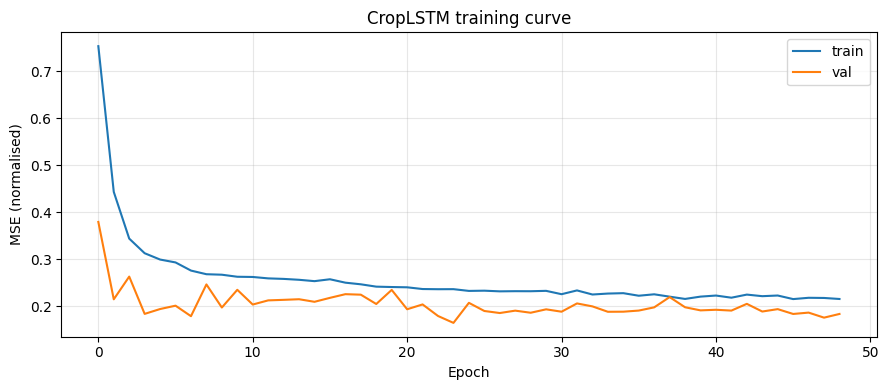

In [7]:
if TORCH_AVAILABLE:
    class CropLSTM(nn.Module):
        def __init__(self, seq_in, sta_in, hidden=128, layers=2, drop=0.3):
            super().__init__()
            self.lstm = nn.LSTM(seq_in, hidden, layers,
                                dropout=drop if layers>1 else 0.0, batch_first=True)
            self.drop = nn.Dropout(drop)
            self.head = nn.Sequential(
                nn.Linear(hidden+sta_in, 64), nn.ReLU(), nn.Dropout(drop), nn.Linear(64, 1))
        def forward(self, xs, xt):
            _, (h, _) = self.lstm(xs)
            return self.head(torch.cat([self.drop(h[-1]), xt], dim=1)).squeeze(1)

    lstm_model = CropLSTM(1, len(STATIC_FEATURES)).to(device)
    print(f'CropLSTM: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,} params')

    def to_t(*arrays):
        return [torch.tensor(a, dtype=torch.float32).to(device) for a in arrays]

    y_tr_n = (y_train - y_mean) / y_std
    y_v_n  = (y_val   - y_mean) / y_std

    tsq_tr, tst_tr, ty_tr = to_t(Xsq_tr, Xst_tr, y_tr_n)
    tsq_v,  tst_v,  ty_v  = to_t(Xsq_v,  Xst_v,  y_v_n)
    tsq_te, tst_te         = to_t(Xsq_te, Xst_te)

    loader = DataLoader(TensorDataset(tsq_tr, tst_tr, ty_tr), batch_size=64, shuffle=True)
    opt    = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)
    crit   = nn.MSELoss()

    best_v, best_s, pat = float('inf'), None, 0
    tr_losses, v_losses = [], []
    print('Training CropLSTM...')

    for ep in range(150):
        lstm_model.train()
        bl = []
        for xsb, xtb, yb in loader:
            opt.zero_grad()
            loss = crit(lstm_model(xsb, xtb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
            opt.step()
            bl.append(loss.item())
        lstm_model.eval()
        with torch.no_grad():
            vl = crit(lstm_model(tsq_v, tst_v), ty_v).item()
        sched.step(vl)
        tr_losses.append(np.mean(bl)); v_losses.append(vl)
        if vl < best_v:
            best_v = vl
            best_s = {k: v.clone() for k, v in lstm_model.state_dict().items()}
            pat = 0
        else:
            pat += 1
        if pat >= 25:
            print(f'  Early stop epoch {ep+1}')
            break
        if (ep+1) % 25 == 0:
            print(f'  Epoch {ep+1:3d} | train={np.mean(bl):.4f} val={vl:.4f}')

    lstm_model.load_state_dict(best_s)
    torch.save(best_s, MODELS_DIR / 'lstm_best.pt')

    lstm_model.eval()
    with torch.no_grad():
        preds['lstm_val']  = lstm_model(tsq_v,  tst_v).cpu().numpy()  * y_std + y_mean
        preds['lstm_test'] = lstm_model(tsq_te, tst_te).cpu().numpy() * y_std + y_mean

    results.append(evaluate('LSTM', y_val,  preds['lstm_val'],  'val'))
    results.append(evaluate('LSTM', y_test, preds['lstm_test'], 'test'))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(tr_losses, label='train'); ax.plot(v_losses, label='val')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (normalised)')
    ax.set_title('CropLSTM training curve'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(DATA_INTERIM / 'lstm_training_curve.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Skipping LSTM')

---
## 3C · Physics-informed neural network

MLP with hybrid loss:
`L_total = L_data + lambda * L_physics`

`L_physics` penalises predictions where increasing `water_stress_frac` does not increase yield — enforcing the agronomic constraint that more water = more yield.

This is the direct analog of the EnKF observation constraint in HyperWind-Now.


In [8]:
if TORCH_AVAILABLE:
    class CropPINN(nn.Module):
        def __init__(self, n_in, hidden=[128,64,32], drop=0.25):
            super().__init__()
            layers, prev = [], n_in
            for h in hidden:
                layers += [nn.Linear(prev,h), nn.ReLU(), nn.Dropout(drop)]
                prev = h
            layers.append(nn.Linear(prev, 1))
            self.net = nn.Sequential(*layers)
        def forward(self, x):
            return self.net(x).squeeze(1)

    def physics_penalty(model, xb, stress_idx, lam=0.15):
        xp = xb.clone()
        xp[:, stress_idx] = (xp[:, stress_idx] + 0.1).clamp(0, 1)
        # water_stress_frac: higher = less stress = more yield
        # so y(xp) should be >= y(xb). penalise violations.
        violations = torch.relu(model(xb) - model(xp))
        return lam * violations.mean()

    stress_idx = FEATURE_COLS.index('water_stress_frac') if 'water_stress_frac' in FEATURE_COLS else 0

    pinn_model = CropPINN(len(FEATURE_COLS)).to(device)
    print(f'CropPINN: {sum(p.numel() for p in pinn_model.parameters() if p.requires_grad):,} params')
    print(f'Physics constraint on col {stress_idx}: water_stress_frac')

    tXtr = torch.tensor(X_train_s, dtype=torch.float32).to(device)
    tXv  = torch.tensor(X_val_s,   dtype=torch.float32).to(device)
    tXte = torch.tensor(X_test_s,  dtype=torch.float32).to(device)
    tytr = torch.tensor((y_train - y_mean)/y_std, dtype=torch.float32).to(device)
    tytv = torch.tensor((y_val   - y_mean)/y_std, dtype=torch.float32).to(device)

    p_loader = DataLoader(TensorDataset(tXtr, tytr), batch_size=64, shuffle=True)
    p_opt    = torch.optim.AdamW(pinn_model.parameters(), lr=1e-3, weight_decay=1e-4)
    p_sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(p_opt, patience=10, factor=0.5)
    p_crit   = nn.MSELoss()

    best_pv, best_ps, ppat = float('inf'), None, 0
    print('Training CropPINN (lambda_physics=0.15)...')

    for ep in range(150):
        pinn_model.train()
        ep_tot, ep_dat, ep_phy = [], [], []
        for xb, yb in p_loader:
            p_opt.zero_grad()
            pred  = pinn_model(xb)
            l_d   = p_crit(pred, yb)
            l_p   = physics_penalty(pinn_model, xb, stress_idx)
            loss  = l_d + l_p
            loss.backward()
            nn.utils.clip_grad_norm_(pinn_model.parameters(), 1.0)
            p_opt.step()
            ep_tot.append(loss.item())
            ep_dat.append(l_d.item())
            ep_phy.append(l_p.item())
        pinn_model.eval()
        with torch.no_grad():
            vl = p_crit(pinn_model(tXv), tytv).item()
        p_sched.step(vl)
        if vl < best_pv:
            best_pv = vl
            best_ps = {k: v.clone() for k, v in pinn_model.state_dict().items()}
            ppat = 0
        else:
            ppat += 1
        if ppat >= 25:
            print(f'  Early stop epoch {ep+1}')
            break
        if (ep+1) % 25 == 0:
            print(f'  Epoch {ep+1:3d} | total={np.mean(ep_tot):.4f}'
                  f' data={np.mean(ep_dat):.4f} phys={np.mean(ep_phy):.4f} val={vl:.4f}')

    pinn_model.load_state_dict(best_ps)
    torch.save(best_ps, MODELS_DIR / 'pinn_best.pt')

    pinn_model.eval()
    with torch.no_grad():
        preds['pinn_val']  = pinn_model(tXv).cpu().numpy()  * y_std + y_mean
        preds['pinn_test'] = pinn_model(tXte).cpu().numpy() * y_std + y_mean

    results.append(evaluate('PINN', y_val,  preds['pinn_val'],  'val'))
    results.append(evaluate('PINN', y_test, preds['pinn_test'], 'test'))
else:
    print('Skipping PINN')

CropPINN: 15,617 params
Physics constraint on col 28: water_stress_frac
Training CropPINN (lambda_physics=0.15)...
  Epoch  25 | total=0.2140 data=0.2020 phys=0.0120 val=0.1852
  Early stop epoch 36
  [PINN      ] val    RMSE=11.74  MAE=9.42  R2=0.653  bias=-1.53
  [PINN      ] test   RMSE=13.56  MAE=10.68  R2=0.334  bias=-1.10


---
## 3D · Stacking ensemble + prediction intervals

Ridge meta-learner on base model predictions. Residual bootstrap for 90% PIs.


In [15]:
meta_tr, meta_v, meta_te = {}, {}, {}

if XGB_AVAILABLE:
    meta_tr['xgb'] = xgb_model.predict(X_train)
    meta_v['xgb']  = preds['xgb_val']
    meta_te['xgb'] = preds['xgb_test']

if TORCH_AVAILABLE:
    lstm_model.eval()
    with torch.no_grad():
        tsq_tr2, tst_tr2 = to_t(Xsq_tr, Xst_tr)
        meta_tr['lstm'] = lstm_model(tsq_tr2, tst_tr2).cpu().numpy() * y_std + y_mean
        meta_v['lstm']  = preds['lstm_val']
        meta_te['lstm'] = preds['lstm_test']
    pinn_model.eval()
    with torch.no_grad():
        meta_tr['pinn'] = pinn_model(torch.tensor(X_train_s, dtype=torch.float32).to(device)).cpu().numpy() * y_std + y_mean
        meta_v['pinn']  = preds['pinn_val']
        meta_te['pinn'] = preds['pinn_test']

if len(meta_tr) == 0:
    print('No models to stack')
else:
    M_tr = np.column_stack(list(meta_tr.values()))
    M_v  = np.column_stack(list(meta_v.values()))
    M_te = np.column_stack(list(meta_te.values()))

    meta = Ridge(alpha=10.0).fit(M_tr, y_train)
    joblib.dump(meta, MODELS_DIR / 'meta_learner.joblib')

    preds['ens_val']  = meta.predict(M_v)
    preds['ens_test'] = meta.predict(M_te)
    results.append(evaluate('Ensemble', y_val,  preds['ens_val'],  'val'))
    results.append(evaluate('Ensemble', y_test, preds['ens_test'], 'test'))

    print(f'\nMeta weights {list(meta_tr.keys())}: {meta.coef_.round(3)}')

    # Prediction intervals
    resid = y_train - meta.predict(M_tr)
    ci_lo = float(np.percentile(resid, 5))
    ci_hi = float(np.percentile(resid, 95))
    ens_lo = preds['ens_test'] + ci_lo
    ens_hi = preds['ens_test'] + ci_hi
    coverage = float(np.mean((y_test >= ens_lo) & (y_test <= ens_hi)))
    print(f'90% PI: [{ci_lo:.1f}, +{ci_hi:.1f}] bu/acre  |  coverage={coverage:.1%}  |  width={ci_hi-ci_lo:.1f}')

  [Ensemble  ] val    RMSE=12.80  MAE=10.68  R2=0.587  bias=-3.12
  [Ensemble  ] test   RMSE=14.04  MAE=11.05  R2=0.286  bias=-7.26

Meta weights ['xgb', 'lstm', 'pinn']: [ 1.405 -0.224 -0.194]
90% PI: [-11.2, +10.8] bu/acre  |  coverage=55.6%  |  width=22.0


---
## 4 · Results and visualisation


In [16]:
results_df = pd.DataFrame(results)
print('=' * 62)
print('  CROPSIGHT CORNBELT — MODEL BENCHMARK')
print('=' * 62)
print(f'{"Model":<12} {"Split":<6} {"RMSE":>8} {"MAE":>8} {"R2":>8} {"Bias":>8}')
print('-' * 62)
for _, r in results_df.sort_values(['split','rmse']).iterrows():
    print(f"{r['model']:<12} {r['split']:<6} {r['rmse']:>8.2f} {r['mae']:>8.2f} {r['r2']:>8.3f} {r['bias']:>+8.2f}")
print('=' * 62)
print('RMSE and MAE in bu/acre')

  CROPSIGHT CORNBELT — MODEL BENCHMARK
Model        Split      RMSE      MAE       R2     Bias
--------------------------------------------------------------
XGBoost      test      12.52     9.68    0.432    -4.38
LSTM         test      12.71    10.05    0.415    +2.53
PINN         test      13.56    10.68    0.334    -1.10
Ensemble     test      14.04    11.05    0.286    -7.26
Ensemble     test      14.04    11.05    0.286    -7.26
Ensemble     test      14.04    11.05    0.286    -7.26
PINN         val       11.74     9.42    0.653    -1.53
XGBoost      val       11.76     9.74    0.651    -1.28
LSTM         val       12.40     9.83    0.612    +4.00
Ensemble     val       12.80    10.68    0.587    -3.12
Ensemble     val       12.80    10.68    0.587    -3.12
Ensemble     val       12.80    10.68    0.587    -3.12
RMSE and MAE in bu/acre


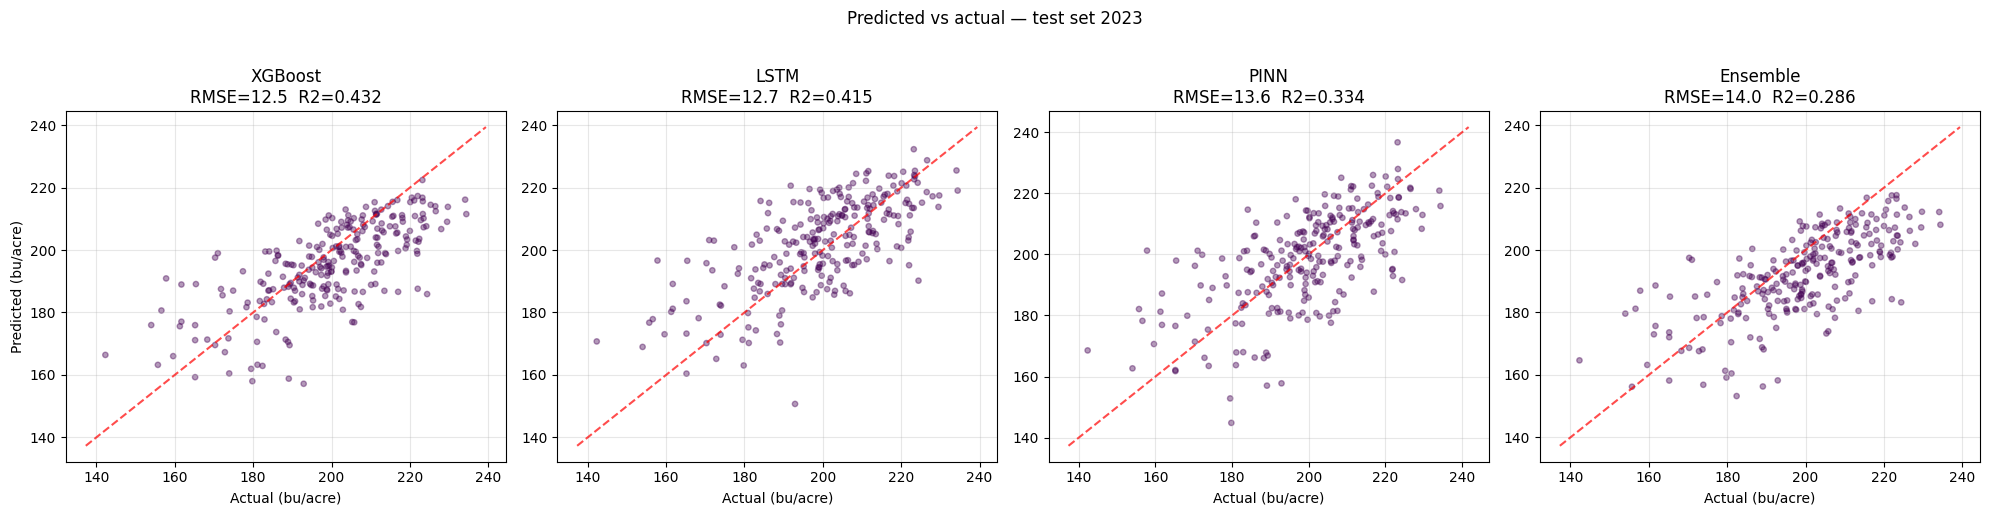

Saved: data/interim/model_predictions_test.png


In [17]:
plot_models = []
if XGB_AVAILABLE:          plot_models.append(('XGBoost',  preds.get('xgb_test')))
if TORCH_AVAILABLE:        plot_models.append(('LSTM',     preds.get('lstm_test')))
if TORCH_AVAILABLE:        plot_models.append(('PINN',     preds.get('pinn_test')))
if 'ens_test' in preds:    plot_models.append(('Ensemble', preds['ens_test']))

n = len([m for m in plot_models if m[1] is not None])
if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    ai = 0
    for name, pred in plot_models:
        if pred is None: continue
        ax = axes[ai]; ai += 1
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2   = r2_score(y_test, pred)
        ax.scatter(y_test, pred, alpha=0.4, s=15,
                   c=test_df['year'].values, cmap='viridis')
        lo = min(y_test.min(), pred.min()) - 5
        hi = max(y_test.max(), pred.max()) + 5
        ax.plot([lo,hi],[lo,hi],'r--',lw=1.5,alpha=0.7)
        ax.set_xlabel('Actual (bu/acre)')
        ax.set_ylabel('Predicted (bu/acre)' if ai==1 else '')
        ax.set_title(f'{name}\nRMSE={rmse:.1f}  R2={r2:.3f}')
        ax.grid(alpha=0.3)
    plt.suptitle('Predicted vs actual — test set 2023', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_INTERIM / 'model_predictions_test.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: data/interim/model_predictions_test.png')

In [18]:
pred_df = test_df[['fips','state','county_name','year','yield_bu_acre']].copy()
if XGB_AVAILABLE:       pred_df['pred_xgb']      = preds.get('xgb_test')
if TORCH_AVAILABLE:     pred_df['pred_lstm']     = preds.get('lstm_test')
if TORCH_AVAILABLE:     pred_df['pred_pinn']     = preds.get('pinn_test')
if 'ens_test' in preds: pred_df['pred_ensemble'] = preds['ens_test']
pred_df['yield_anomaly'] = pred_df['yield_bu_acre'] - pred_df['yield_bu_acre'].mean()

full_pred = pd.read_parquet(DATA_INTERIM / 'feature_matrix.parquet')[
    ['fips','state','county_name','year','yield_bu_acre']].copy()
if XGB_AVAILABLE:
    fm = pd.read_parquet(DATA_INTERIM / 'feature_matrix.parquet')
    full_pred['pred_xgb'] = xgb_model.predict(
        fm[FEATURE_COLS].values.astype(np.float32))

pred_df.to_parquet(DATA_INTERIM / 'predictions_test.parquet', index=False)
full_pred.to_parquet(DATA_INTERIM / 'predictions_full.parquet', index=False)
print(f'Saved predictions_test.parquet  ({len(pred_df)} rows)')
print(f'Saved predictions_full.parquet  ({len(full_pred)} rows)')

Saved predictions_test.parquet  (252 rows)
Saved predictions_full.parquet  (6620 rows)


In [19]:
print('=' * 55)
print('  MODULE 3 COMPLETE')
print('=' * 55)
for f in sorted(MODELS_DIR.glob('*')):
    print(f'  {f.name:<38} {f.stat().st_size/1e3:.0f} KB')
print()
test_r = results_df[results_df['split']=='test'].sort_values('rmse')
print('Test RMSE ranking:')
for _, r in test_r.iterrows():
    print(f"  {r['model']:<12} RMSE={r['rmse']:.2f}  R2={r['r2']:.3f}")
print('\n  -> Next: Module 4 — dashboard.py')

  MODULE 3 COMPLETE
  lstm_best.pt                           836 KB
  meta_learner.joblib                    1 KB
  pinn_best.pt                           66 KB
  scaler.joblib                          2 KB
  xgboost_baseline.json                  1625 KB

Test RMSE ranking:
  XGBoost      RMSE=12.52  R2=0.432
  LSTM         RMSE=12.71  R2=0.415
  PINN         RMSE=13.56  R2=0.334
  Ensemble     RMSE=14.04  R2=0.286
  Ensemble     RMSE=14.04  R2=0.286
  Ensemble     RMSE=14.04  R2=0.286

  -> Next: Module 4 — dashboard.py
